In [2]:
import numpy as np
from matplotlib import pyplot as plt

Task 1. Simulate a path of the Wiener process. Number of end-points of the grid including $T$ is $N=100$, length of the interval $[0, T]$ in time units is 1, time increment is $\Delta = T/N$. Plot the path.

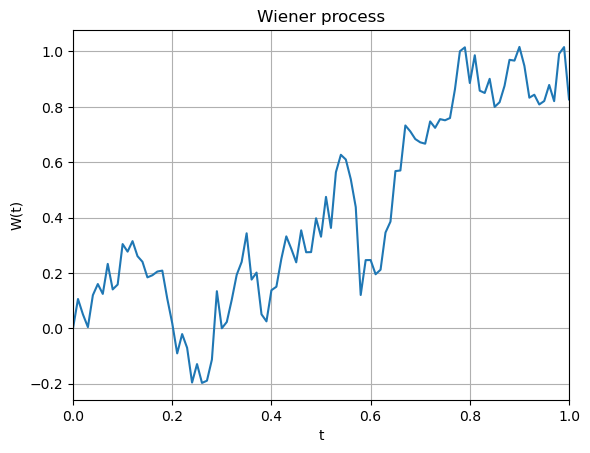

In [2]:
def WienerRandomValue(t):
    return np.sqrt(t) * np.random.normal(0, 1)


def WienerProcess(N, T):
    t_data = np.linspace(0, T, N + 1)
    w_data = np.zeros(N + 1)
    dt = T/N
    for i in range(1, N + 1):
        w_data[i] = w_data[i - 1] + WienerRandomValue(dt)
    return t_data, w_data

N = 100
T = 1
t_data, w_data = WienerProcess(N, T)

plt.plot(t_data, w_data)
plt.xlabel("t")
plt.ylabel("W(t)")
plt.xlim(0.0, T)
plt.title("Wiener process")
plt.grid(True)
plt.show()

Task 2. Using the random walk algorithm simulate three paths of the Wiener process as the limit of a random walk for different $n=10, 100, 1000$. Plot the paths in one figure, add the legend.

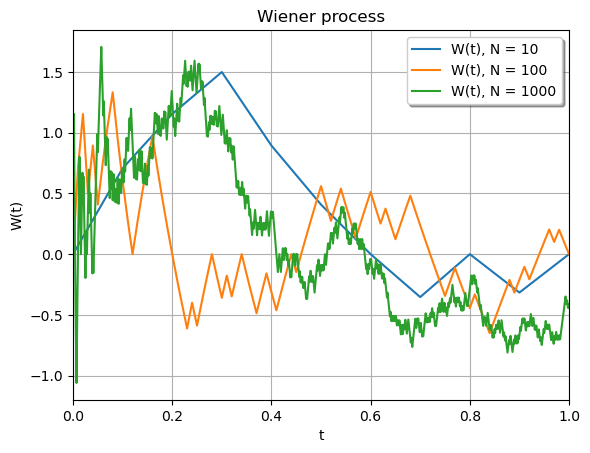

In [3]:
def RandomValueP(p):
    assert p > 0.0 and p < 1.0, '0 < p < 1'

    rand = np.random.uniform(0, 1)
    if rand <= p:
        return 1
    else:
        return -1

def RandomWalk(p, N):
    t_data = np.linspace(0, 1, N + 1)
    w_data = np.zeros(N + 1)
    for i in range(1, N + 1):
        w_data[i] = w_data[i - 1] * np.sqrt(i / (i + 1)) + RandomValueP(p) / np.sqrt(i + 1)
    return t_data, w_data

p = 0.5
N = [10, 100, 1000]
for k in N:
    t_data, w_data = RandomWalk(p, k)
    plt.plot(t_data, w_data, label = f"W(t), N = {k}")

plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlim(0.0, 1.0)
plt.xlabel("t")
plt.ylabel("W(t)")
plt.title("Wiener process")
plt.grid(True)
plt.show()

Task 3. Using the the Karhunen-Loeve expansion simulate three paths of the Wiener process with
$n = 10, 50, 100$ terms. Plot the paths in one figure, add legends.

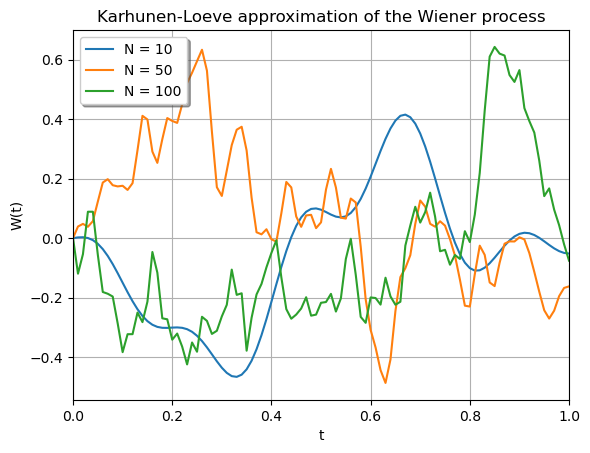

In [4]:
def phi(k, t, T):
    return 2 * np.sqrt(2 * T) / np.pi / (2 * k + 1) * np.sin((2 * k + 1) * np.pi * t / (2 * T))

def KarhunenLoeveApprox(T, Nt, Nz):
    z_data = np.random.normal(0, 1, size = Nz)
    t_data = np.linspace(0, T, Nt + 1)
    k = np.arange(0, len(z_data)) + 1
    w_data = np.zeros(Nt + 1)
    for i in range(0, Nt + 1):
        phi_data = phi(k, t_data[i], T)
        w_data[i] = np.dot(z_data, phi_data)
    return t_data, w_data

T = 1
Nt = 100
Nz = [10, 50, 100]

for k in Nz:
    t_data, w_data = KarhunenLoeveApprox(T, Nt, k)
    plt.plot(t_data, w_data, label = f'N = {k}')

plt.legend(loc = 'upper left', fancybox = True, shadow = True)
plt.xlim(0.0, 1.0)
plt.xlabel("t")
plt.ylabel("W(t)")
plt.title("Karhunen-Loeve approximation of the Wiener process")
plt.grid(True)
plt.show()

Task 4. Plot a trajectory of the geometric Brownian motion obtained from the simulation of the path of the Wiener process, $r=1$ (interest rate) and $\sigma = 0.5$ (volatility).

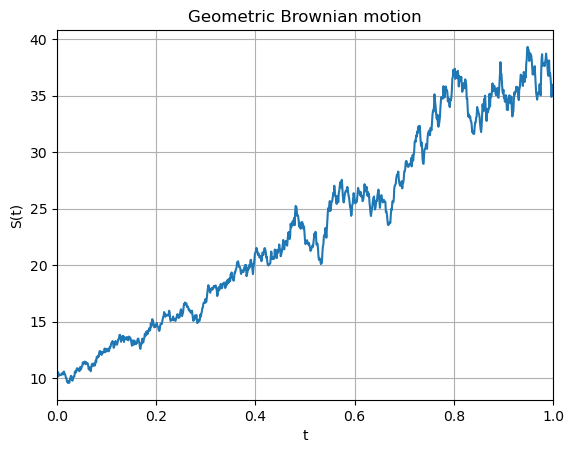

In [5]:
def GeometricBrownianMotion(S0, r, sigma, T):
    Nt = 1000
    t_data = np.linspace(0, T, Nt + 1)
    s_data = np.zeros(Nt + 1)
    s_data[0] = S0
    dt = T / Nt
    for i in range(1, Nt + 1):
        s_data[i] = s_data[i-1] * np.exp((r - sigma**2 / 2)* dt + sigma * WienerRandomValue(dt))
    return t_data, s_data

S0 = 10
r = 1
sigma = 0.5
T = 1

t_data, s_data = GeometricBrownianMotion(S0, r, sigma, T)
plt.plot(t_data, s_data)
plt.xlim(0.0, 1.0)
plt.xlabel("t")
plt.ylabel("S(t)")
plt.title("Geometric Brownian motion")
plt.grid(True)
plt.show()

Task 5. Plot a trajectory of the the Brownian bridge starting at $x$ at time $0$ and terminating its run at $y =-1$ at time $T$ obtained from the simulation of the path of the Wiener process. Add markers for start and end points.

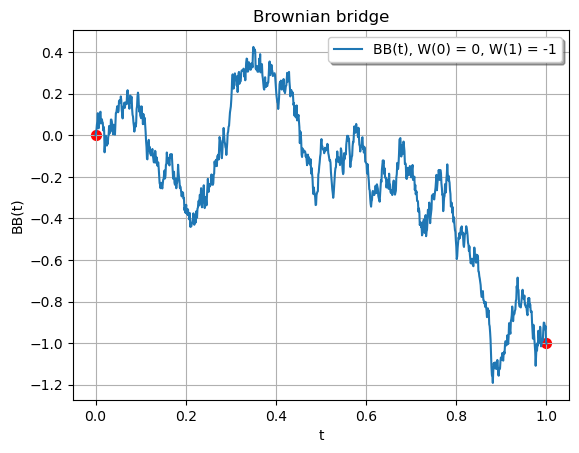

In [6]:
def BrownianBridge(x, y, t0, T):
    Nt = 1000
    t_data, w_data = WienerProcess(Nt, T)
    dt = T/Nt
    bb_data = np.zeros(Nt + 1)
    for i in range(0, Nt + 1):
        bb_data[i] = x + w_data[i] - (t_data[i] - t0) / (T - t0) * (w_data[Nt - 1] - y + x)
    return t_data, bb_data

x = 0
y = -1
t0 = 0
T = 1
t_data, bb_data = BrownianBridge(x, y, t0, T)

plt.plot(t_data, bb_data, label = f"BB(t), W({t0}) = {x}, W({T}) = {y}")
plt.scatter ( t0, x, color = "red", s = 50)
plt.scatter ( T, y, color = "red", s = 50)
plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("BB(t)")
plt.title("Brownian bridge")
plt.grid(True)
plt.show()

# Exercises

Exercise 1. Let us consider a random walk $X = (X_n)_{n \geq 0}$:
$$
X_n = \sum_{k=1}^n \xi_k, \quad \xi_k =
\begin{cases}
1, &\text{with probability $\frac12$}; \\
-1, &\text{with probability $\frac12$}.
\end{cases}
$$
$$
\mathbb{E}\xi_k = 0, \quad \mathrm{Var}\, \xi_k = 1.
$$

Plot $(X_{t_i})_{t_i = \frac{i}{n}}$ so that $t_i$ takes values in $[0,\, 1]$.

In [7]:
def RandomWalk(N, p=[0.5, 0.5]):
    # Генерируем случайные шаги
    xi = np.random.choice([-1, 1], size=N, p=p)

    # Вычисляем случайное блуждание
    X = np.cumsum(xi)  # Кумулятивная сумма шагов

    # Добавляем начальную позицию (0)
    X = np.insert(X, 0, 0)  # Добавляем X_0 = 0 в начало

    # Создаем массив t
    t = np.linspace(0, 1, N + 1)  # n + 1 точек для t_i

    # Строим график
    plt.figure(figsize=(10, 5))
    plt.plot(t, X, marker='o', linestyle='-')
    plt.title('Random Walk')
    plt.xlabel('t')
    plt.ylabel('$X_n$')
    plt.grid()
    plt.show()

Exercise 2. Let $H = (H_n)_{n \geq 1}$ be the player's bet at the $n$-th step, i.e. his winnings at this step are equal to $H_n (X_n - X_{n-1}) = H_n \Delta X_n$.

Plot an accumulated winnings of player $Y_n$ at step $n \geq 1$.


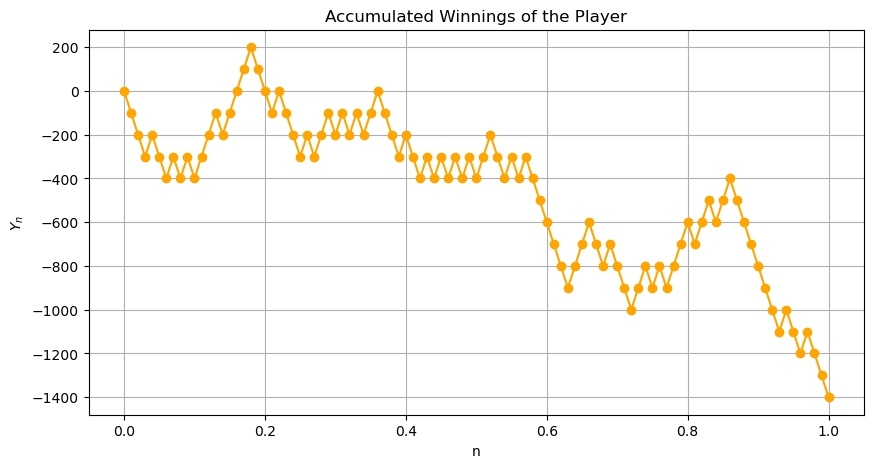

In [8]:
def random_walk_with_bets(n, H):
    # Генерируем случайные шаги
    xi = np.random.choice([-1, 1], size=n, p=[0.5, 0.5])

    # Вычисляем случайное блуждание
    X = np.cumsum(xi)

    # Добавляем начальную позицию (0)
    X = np.insert(X, 0, 0)  # Добавляем X_0 = 0 в начало

    # Вычисляем накопленные выигрыши
    Y = np.zeros(n + 1)  # Начинаем с 0
    for i in range(1, n + 1):
        Y[i] = Y[i - 1] + H * (X[i] - X[i - 1])  # Y_n = Y_{n-1} + H * ΔX_n

    # Создаем массив t
    t = np.linspace(0, 1, n + 1)  # n + 1 точек для t_i

    # Строим график накопленных выигрышей
    plt.figure(figsize=(10, 5))
    plt.plot(t, Y, marker='o', linestyle='-', color='orange')
    plt.title('Accumulated Winnings of the Player')
    plt.xlabel('n')
    plt.ylabel('$Y_n$')
    plt.grid()
    plt.show()

# Пример вызова функции с n = 100 и H = 1
random_walk_with_bets(100, H=100)

# Задачи

Задача 1. Квадратичная вариация (Раздел 1.1.2)

Для траектории винеровского процесса при $T=1$ и разного числа интервалов разбиения $\{10,100,1000,10000\}$:

1. Вычислите сумму квадратов приращений $$ S_n= ∑_{k=0}^{n−1}​ ∣W(t_{k+1} )−W(t_k​ )∣^2.$$

2. Постройте график зависимости суммы $S_n$ от числа интервалов разбиения (столбчатую диаграмму).

3. Сделайте выводы.

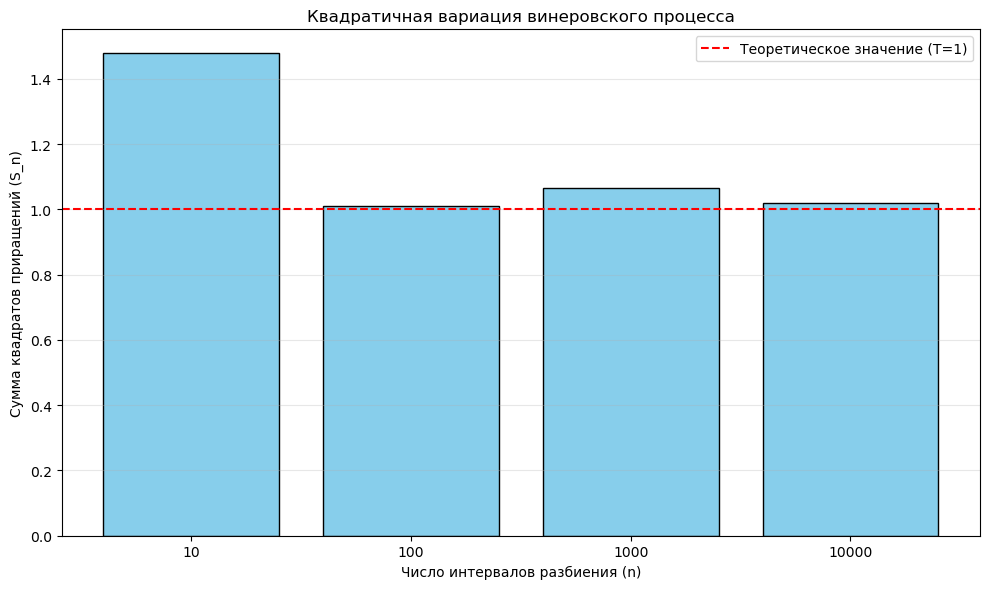

In [4]:
def WienerProcess(N, T):
    t_data = np.linspace(0, T, N + 1)
    w_data = np.zeros(N + 1)
    dt = T / N
    for i in range(1, N + 1):
        w_data[i] = w_data[i - 1] + np.sqrt(dt) * np.random.normal(0, 1)
    return t_data, w_data

def quadratic_variation(N, T=1):
    t_data, w_data = WienerProcess(N, T)
    dt = T / N
    S_n = np.sum(np.diff(w_data) ** 2)
    return S_n

n_values = [10, 100, 1000, 10000]
S_n_values = [quadratic_variation(n) for n in n_values]

# Построение графика
plt.figure(figsize=(10, 6))
plt.bar([str(n) for n in n_values], S_n_values, color='skyblue', edgecolor='black')
plt.axhline(y=1.0, color='red', linestyle='--', label='Теоретическое значение (T=1)')
plt.xlabel('Число интервалов разбиения (n)')
plt.ylabel('Сумма квадратов приращений (S_n)')
plt.title('Квадратичная вариация винеровского процесса')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


Задача 2. Эмпирическая ковариационная функция (Раздел 1.1.3)

Для винеровского процесса теоретическая ковариация между состояниями в моменты времени $s$ и $t$ равна $\min(s,t)$.

1. Сгенерируйте ансамбль из 500 траекторий винеровского процесса.

2. Вычислите выборочную ковариацию между точками $t=0.5$ и $t=T$ и сравните полученное число с теоретическим значением $0.5$.

3. Сделайте выводы.

Эмпирическая ковариационная функция:
Время s = 0.5, Время T = 1.0
Эмпирическая ковариация: 0.490038
Теоретическая ковариация: 0.500000
Относительная ошибка: 1.99%


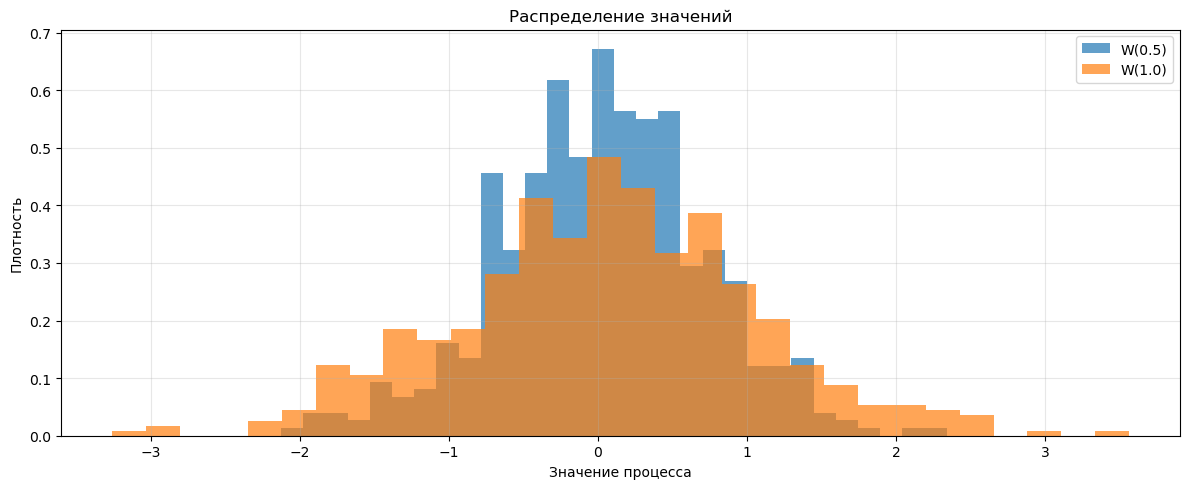

In [5]:
def generate_ensemble(num_trajectories, N, T=1):

    trajectories = np.zeros((num_trajectories, N + 1))
    dt = T / N
    for i in range(num_trajectories):
        _, w_data = WienerProcess(N, T)
        trajectories[i, :] = w_data
    return trajectories

num_trajectories = 500
N = 1000
T = 1.0
t_s = 0.5
t_T = 1.0

# Генерация ансамбля
trajectories = generate_ensemble(num_trajectories, N, T)
t_data = np.linspace(0, T, N + 1)

# Нахождение индексов
idx_s = int(t_s / T * N)
idx_T = int(t_T / T * N)

# Вычисление выборочной ковариации
W_s = trajectories[:, idx_s]
W_T = trajectories[:, idx_T]

# Ковариация
cov_empirical = np.cov(W_s, W_T)[0, 1]
cov_theoretical = min(t_s, t_T)

# Вывод результатов
print("Эмпирическая ковариационная функция:")
print("=" * 50)
print(f"Время s = {t_s}, Время T = {t_T}")
print(f"Эмпирическая ковариация: {cov_empirical:.6f}")
print(f"Теоретическая ковариация: {cov_theoretical:.6f}")
print(f"Относительная ошибка: {abs(cov_empirical - cov_theoretical) / cov_theoretical * 100:.2f}%")
print("=" * 50)

# Визуализация
plt.figure(figsize=(12, 5))

plt.hist(W_s, bins=30, alpha=0.7, label=f'W({t_s})', density=True)
plt.hist(W_T, bins=30, alpha=0.7, label=f'W({t_T})', density=True)
plt.xlabel('Значение процесса')
plt.ylabel('Плотность')
plt.title('Распределение значений')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Задача 3. Тестирование мартингального свойства (Раздел 1.1.5)

1. Сгенерируйте ансамбль из 500 траекторий винеровского процесса.

2. Выберите фиксированный момент времени $s=0.4$.

3. Для всех сгенерированных траекторий, проходящих через определенный узкий диапазон значений в момент $s$, вычислите среднее арифметическое их значений в финальный момент $T$.

4. Сравните полученное среднее арифметическое со значением процесса в момент $s$.

5. Сделайте выводы. Проанализовать как диапозон влияет на результат.

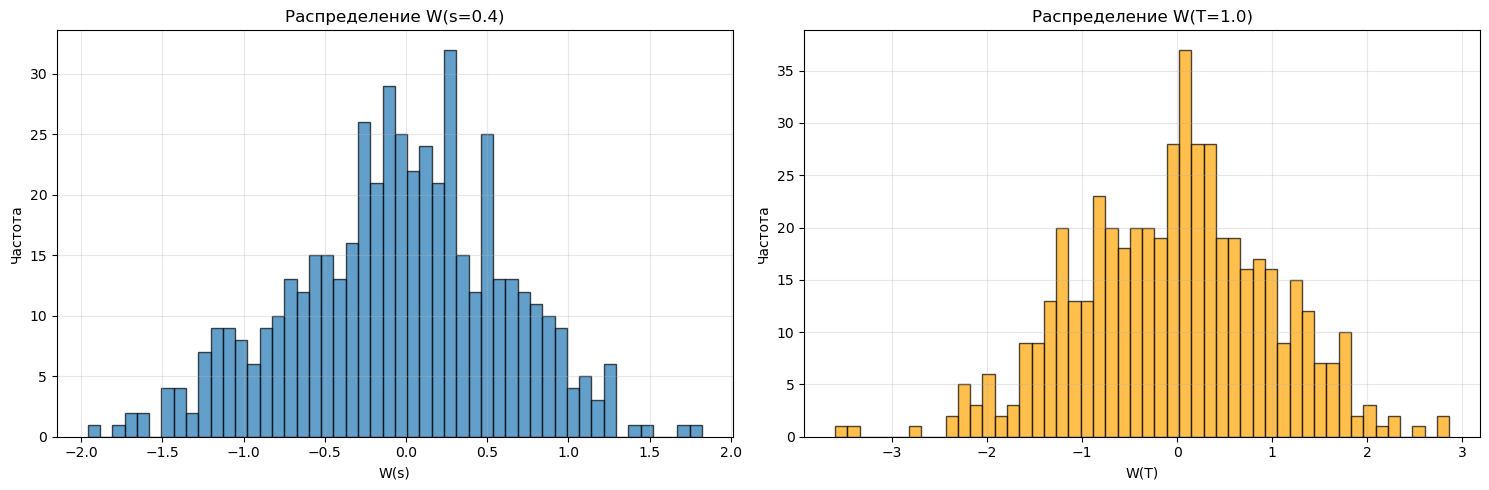

In [19]:
def test_martingale_property(num_trajectories=500, N=1000, T=1.0, s=0.4, 
                             range_widths=[0.1, 0.05, 0.02, 0.01]):
    """Тестирование мартингального свойства"""
    
    trajectories = generate_ensemble(num_trajectories, N, T)
    t_data = np.linspace(0, T, N + 1)
    
    idx_s = int(s / T * N)
    idx_T = N
    
    W_s = trajectories[:, idx_s]
    W_T = trajectories[:, idx_T]
    
    results = []

    for width in range_widths:
        # Выбираем траектории в диапазоне
        mask = (W_s >= -width/2) & (W_s <= width/2)
        num_selected = np.sum(mask)
        
        if num_selected > 0:
            mean_W_T = np.mean(W_T[mask])
            mean_W_s = np.mean(W_s[mask])
            diff = mean_W_T - mean_W_s
            
            results.append({
                'width': width,
                'num_selected': num_selected,
                'mean_W_T': mean_W_T,
                'mean_W_s': mean_W_s,
                'diff': diff
            })

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 2, 1)
    plt.hist(W_s, bins=50, alpha=0.7, edgecolor='black')
    plt.xlabel('W(s)')
    plt.ylabel('Частота')
    plt.title(f'Распределение W(s={s})')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.hist(W_T, bins=50, alpha=0.7, edgecolor='black', color='orange')
    plt.xlabel('W(T)')
    plt.ylabel('Частота')
    plt.title(f'Распределение W(T={T})')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return results

results = test_martingale_property()


Задача 4. Анализ независимости приращений (Раздел 1.2)

1. Выберите два непересекающихся интервала $[t_1, t_2​]$ и $[t_3, t_4​]$.
2. Сгенерируйте $M$ траекторий и вычислите приращения
$ΔW_1 =W(t_2)−W(t_1)$ и $ΔW_2 =W(t_4)−W(t_3)$.

3. Постройте диаграмму рассеяния (scatter plot) для $(ΔW_1, ΔW_2)$ и вычислите коэффициент корреляции.

4. Сравните полученное значение с нулем и сделайте выводы.

Анализ независимости приращений:
Интервал 1: [0.1, 0.3], длина = 0.200
Интервал 2: [0.6, 0.8], длина = 0.200
ΔW1: Среднее = -0.017584, Стд.откл. = 0.442071 (теор. 0.447214)
ΔW2: Среднее = 0.005377, Стд.откл. = 0.447841 (теор. 0.447214)
Коэффициент корреляции: 0.006515
Теоретическая корреляция: 0.0 (независимые приращения)


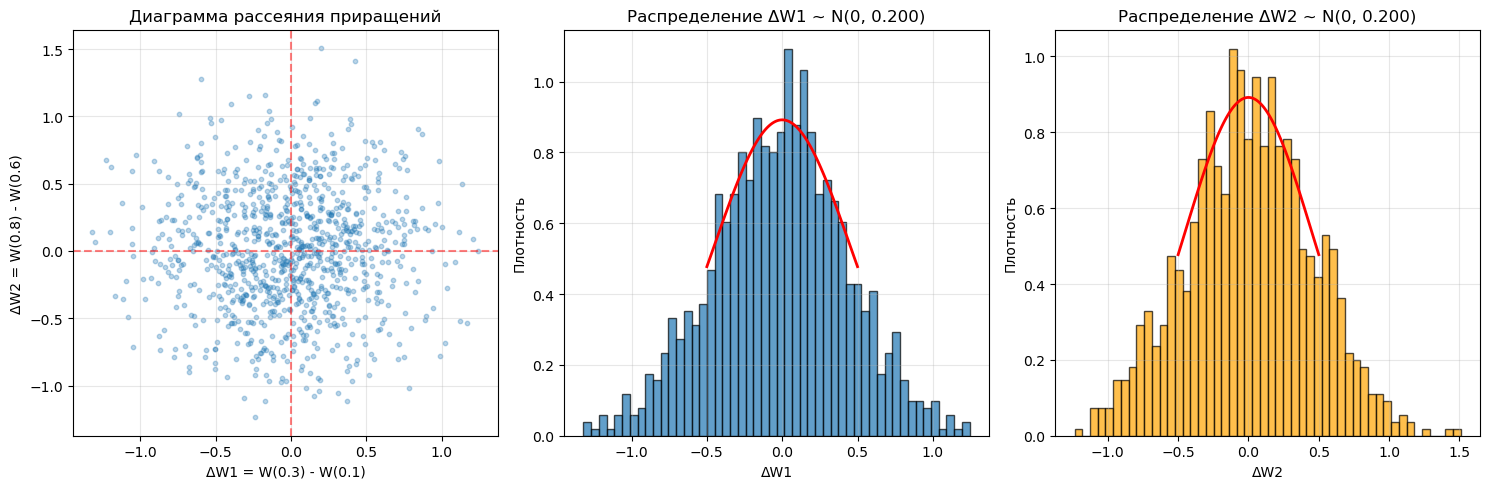

In [15]:
def test_increment_independence(num_trajectories=1000, N=1000, T=1.0,
                                 t1=0.1, t2=0.3, t3=0.6, t4=0.8):
    """Тестирование независимости приращений"""
    
    trajectories = generate_ensemble(num_trajectories, N, T)
    
    # Нахождение индексов
    idx_t1 = int(t1 / T * N)
    idx_t2 = int(t2 / T * N)
    idx_t3 = int(t3 / T * N)
    idx_t4 = int(t4 / T * N)
    
    # Вычисление приращений
    delta_W1 = trajectories[:, idx_t2] - trajectories[:, idx_t1]
    delta_W2 = trajectories[:, idx_t4] - trajectories[:, idx_t3]
    
    # Коэффициент корреляции
    correlation = np.corrcoef(delta_W1, delta_W2)[0, 1]
    
    # Статистика приращений
    mean_dW1 = np.mean(delta_W1)
    std_dW1 = np.std(delta_W1)
    mean_dW2 = np.mean(delta_W2)
    std_dW2 = np.std(delta_W2)
    
    # Теоретические значения
    var_dW1 = t2 - t1
    var_dW2 = t4 - t3
    
    print("Анализ независимости приращений:")
    print("=" * 70)
    print(f"Интервал 1: [{t1}, {t2}], длина = {t2-t1:.3f}")
    print(f"Интервал 2: [{t3}, {t4}], длина = {t4-t3:.3f}")
    print("=" * 70)
    print(f"ΔW1: Среднее = {mean_dW1:.6f}, Стд.откл. = {std_dW1:.6f} (теор. {np.sqrt(var_dW1):.6f})")
    print(f"ΔW2: Среднее = {mean_dW2:.6f}, Стд.откл. = {std_dW2:.6f} (теор. {np.sqrt(var_dW2):.6f})")
    print(f"Коэффициент корреляции: {correlation:.6f}")
    print(f"Теоретическая корреляция: 0.0 (независимые приращения)")
    print("=" * 70)
    
    # Визуализация
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.scatter(delta_W1, delta_W2, alpha=0.3, s=10)
    plt.xlabel(f'ΔW1 = W({t2}) - W({t1})')
    plt.ylabel(f'ΔW2 = W({t4}) - W({t3})')
    plt.title('Диаграмма рассеяния приращений')
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
    
    plt.subplot(1, 3, 2)
    plt.hist(delta_W1, bins=50, alpha=0.7, edgecolor='black', density=True)
    x = np.linspace(-0.5, 0.5, 100)
    plt.plot(x, 1/np.sqrt(2*np.pi*var_dW1) * np.exp(-x**2/(2*var_dW1)), 'r-', linewidth=2)
    plt.xlabel('ΔW1')
    plt.ylabel('Плотность')
    plt.title(f'Распределение ΔW1 ~ N(0, {var_dW1:.3f})')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 3, 3)
    plt.hist(delta_W2, bins=50, alpha=0.7, edgecolor='black', density=True, color='orange')
    x = np.linspace(-0.5, 0.5, 100)
    plt.plot(x, 1/np.sqrt(2*np.pi*var_dW2) * np.exp(-x**2/(2*var_dW2)), 'r-', linewidth=2)
    plt.xlabel('ΔW2')
    plt.ylabel('Плотность')
    plt.title(f'Распределение ΔW2 ~ N(0, {var_dW2:.3f})')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return correlation

# Запуск теста
correlation = test_increment_independence()


Задача 5. Точность разложения Карунена-Лоэва (Раздел 1.2.3)

1. Реализуйте аппроксимацию винеровской траектории, используя $n=10, 100, 1000$ слагаемых.
2. Рассчитайте среднеквадратичную ошибку между прямой симуляцией и аппроксимацией Карунена-Лоэва.

3. Постройте график зависимости ошибки при увеличении числа членов ряда $n$.
4. Сделайте выводы.


Точность разложения Карунена-Лоэва:
n (число членов)     MSE                  RMSE                
10                   0.18914219           0.43490481          
100                  0.11290803           0.33601790          
1000                 0.18668977           0.43207611          


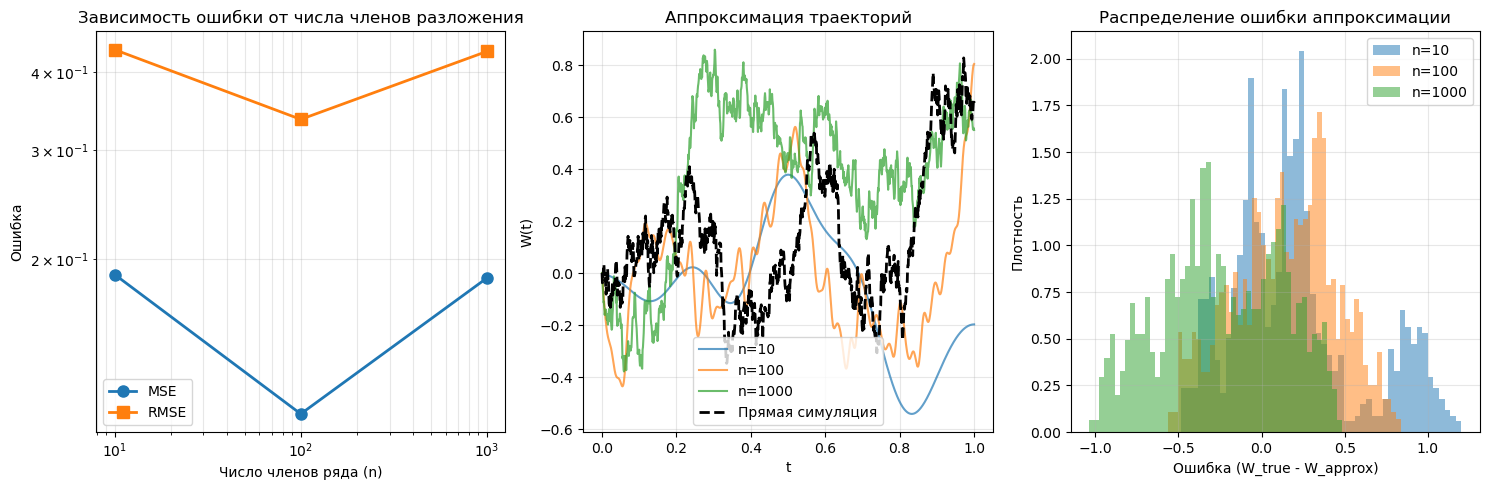

In [26]:
def karhunen_loeve_approximation(T=1.0, Nt=1000, n_terms=10):
    """Аппроксимация винеровского процесса разложением Карунена-Лоэва"""
    
    t_data = np.linspace(0, T, Nt + 1)
    w_data = np.zeros(Nt + 1)
    
    # Генерация случайных коэффициентов
    Z = np.random.normal(0, 1, n_terms)
    
    for i, t in enumerate(t_data):
        for k in range(n_terms):
            phi_k = 2 * np.sqrt(2 * T) / ((2 * k + 1) * np.pi) * \
                    np.sin((2 * k + 1) * np.pi * t / (2 * T))
            w_data[i] += Z[k] * phi_k
    
    return t_data, w_data

def direct_wiener_simulation(Nt=1000, T=1.0):
    """Прямая симуляция винеровского процесса"""
    return WienerProcess(Nt, T)

def calculate_mse(w_true, w_approx):
    """Вычисление среднеквадратичной ошибки"""
    return np.mean((w_true - w_approx) ** 2)

# Параметры
T = 1.0
Nt = 1000
n_values = [10, 100, 1000]

# Прямая симуляция (эталон)
t_data, w_true = direct_wiener_simulation(Nt, T)

# Вычисление ошибок для разных n
mse_values = []
approx_trajectories = []

print("Точность разложения Карунена-Лоэва:")
print("=" * 70)
print(f"{'n (число членов)':<20} {'MSE':<20} {'RMSE':<20}")
print("=" * 70)

for n in n_values:
    _, w_approx = karhunen_loeve_approximation(T, Nt, n)
    mse = calculate_mse(w_true, w_approx)
    rmse = np.sqrt(mse)
    mse_values.append(mse)
    approx_trajectories.append(w_approx)
    
    print(f"{n:<20} {mse:<20.8f} {rmse:<20.8f}")

print("=" * 70)

# Визуализация
plt.figure(figsize=(15, 5))

# График 1: Зависимость ошибки от n
plt.subplot(1, 3, 1)
plt.loglog(n_values, mse_values, 'o-', linewidth=2, markersize=8, label='MSE')
plt.loglog(n_values, np.sqrt(mse_values), 's-', linewidth=2, markersize=8, label='RMSE')
plt.xlabel('Число членов ряда (n)')
plt.ylabel('Ошибка')
plt.title('Зависимость ошибки от числа членов разложения')
plt.legend()
plt.grid(True, alpha=0.3, which='both')

# График 2: Траектории для разных n
plt.subplot(1, 3, 2)
colors = ['blue', 'green', 'orange', 'red']
for i, n in enumerate([10, 100, 1000]):
    idx = n_values.index(n)
    plt.plot(t_data, approx_trajectories[idx], label=f'n={n}', alpha=0.7)
plt.plot(t_data, w_true, 'k--', linewidth=2, label='Прямая симуляция')
plt.xlabel('t')
plt.ylabel('W(t)')
plt.title('Аппроксимация траекторий')
plt.legend()
plt.grid(True, alpha=0.3)

# График 3: Распределение ошибки
plt.subplot(1, 3, 3)
for i, n in enumerate([10, 100, 1000]):
    idx = n_values.index(n)
    error = w_true - approx_trajectories[idx]
    plt.hist(error, bins=50, alpha=0.5, label=f'n={n}', density=True)
plt.xlabel('Ошибка (W_true - W_approx)')
plt.ylabel('Плотность')
plt.title('Распределение ошибки аппроксимации')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
